# ANÁLISIS EXPLORATORIO Y LIMPIEZA DE LOS DATOS

Este _Notebook_ está dedicado a la preparación del dataset para poder aplicar los distintos modelos que se desarrollarán durante el estudio y a la comprensión del conjunto de datos limpio, con el propósito de entender la naturaleza del riesgo que suscribiría una compañía con la cartera de clientes y siniestros a estudio. Técnicas estadísticas y de visualización nos permitirán resumir características, patrones y estructuras subyacentes de la base de datos.

##### Setup del Notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

##### Carga del Conjunto de Datos

In [3]:
data_path = "../data/raw/"
df_original = pd.read_csv(data_path + "WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv")
df_original.head(3)

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize


### LIMPIEZA Y PREPARACIÓN de los DATOS

En una primera instancia llevaremos a cabo labores de exploración y validación de la base de datos:
- Buscamos valores nulos o duplicados en la base de datos y actuaremos sobre ellos de forma que no supongan un problema en la realización de nuestro estudio.
- Examinamos las variables y comprobamos que sus valores y rangos son coherentes, (p.ej: Coste de un siniestro negativo).
- Tratamiento de las variables Fecha

Comenzamos recogiendo información sobre nuestro conjunto de datos.

In [4]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   str    
 1   State                          9134 non-null   str    
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   str    
 4   Coverage                       9134 non-null   str    
 5   Education                      9134 non-null   str    
 6   Effective To Date              9134 non-null   str    
 7   EmploymentStatus               9134 non-null   str    
 8   Gender                         9134 non-null   str    
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   str    
 11  Marital Status                 9134 non-null   str    
 12  Monthly Premium Auto           9134 non-null   int64  
 13 

Vemos que la variable `Effective To Date` tiene formato fecha pero aparece como `str`. Además, vemos que parece no hay valores perdido o `nulls`. Comprobamos a continuación si hay valores duplicados, para ello chequeamos que todos los clientes son únicos y en tal caso que no hay dos filas que sean completamente iguales a excepción del id de cliente.



In [5]:
Customer_IDs = df_original["Customer"]
if len(Customer_IDs) == len(set(Customer_IDs)):
    print("Todos los clientes tienen ID único.")
vbles_analisis = df_original.columns[1:]
if df_original.duplicated(subset=vbles_analisis).any():
    print(f"Hay filas {df_original.duplicated(subset=vbles_analisis).sum()} clientes con los mismos valores en las columnas de análisis.")

Todos los clientes tienen ID único.
Hay filas 163 clientes con los mismos valores en las columnas de análisis.


Vemos que hay 163 filas repetidas de las 9134 filas del dataset original. Esto es menos de un 2% del total, sin embargo observamos que columnas como el `Customer Lifetime Value` tiene hasta 6 decimales, con lo cual asumimos que estas filas son ruido que nos va a ensuciar nuestra base de datos que se ha generado al ser una base de datos sintética. Descartamos estas observaciones.

In [6]:
df_limpio = df_original.drop_duplicates(subset=vbles_analisis)
print(f"Se eliminaron {len(df_original) - len(df_limpio)} filas duplicadas.")
df_limpio["Total Claim Amount"] = df_limpio["Total Claim Amount"].round(2)

Se eliminaron 163 filas duplicadas.


Transformamos la variable `Effective To Date` a formato fecha

In [7]:
df_limpio['Effective To Date'] = pd.to_datetime(df_limpio['Effective To Date'], format='mixed').dt.date

print(df_limpio['Effective To Date'].describe())
print("Fecha inicial: ", df_limpio['Effective To Date'].min())
print("Fecha final: ", df_limpio['Effective To Date'].max())

count           8971
unique            59
top       2011-01-27
freq             191
Name: Effective To Date, dtype: object
Fecha inicial:  2011-01-01
Fecha final:  2011-02-28


### Tratamiento Variables Explicativas Categóricas

En primer lugar debemos identificar cuales son nuestras variables categóricas y clasificarlas de acuerdo a si son ordinales (como el tipo de cobertura, _básica_, _premium_ o _extendida) o nominales (como el estado de EE.UU. al que pertenece el asegurado).

Si nos fijamos en nuestras variables podemos identificar las siguientes variables **categóricas nominales**:

- `State` ------------------> Se refiere al estado de EE.UU. en el que reside el asegurado. Puede ser _California_, _Oregón_, _Arizona_, _Nevada_ o _Washington_.
- `Response` ---------------> Indica si el cliente respondió _Si_ o _No_ a la última campaña de marketing o renovación. Dicotómica. Útil a nivel marketing pero no para nuestro modelo.
- `Employment Status` ------> Determina cual es la situación laboral del asegurado. Los valores posibles son _Employed_, _Unemployed_, _Medical Leave_, _Disabled_ o _Retired_.
- `Gender` -----------------> Hombre o mujer, de nuevo será útil a nivel descriptivo.
- `Location Code` ----------> Zona de residencia. Útil para tarificación territorial. _Suburban_, _Rural_ o _Urban_.
- `Marital Status` ---------> _Married_, _Single_ o _Divorced_.
- `Policy Type` ------------> Define el tipo de poliza del cliente. Es relevante porque posteriormente veremos una variable `Policy` que recoge este tipo de poliza junto a un nivel siendo una variable mixta al recoger tres categorías distintas con orden interno dentro de cada una. Usamos esta variable para recoger el tipo de poliza y la variable `Policy Level` recogerá a que nivel está la poliza.
- `Sales Chanel` -----------> El canal por el cual se llegó al asegurado: _Agent_, _Branch_, _Call Center_ o _Web_. Descartada, marketing
- `Vehicle Class` ----------> _Four-Door Car_, _Two-Door Car_, _SUV_, _Sports Car_, _Luxury SUV_ o _Luxury Car_.

A continuación, observamos en cuales de las variables categóricas definen un orden interno o son **categóricas ordinales**:

- `Coverage`. --------------> El tipo de cobertura puede ser _Basic_, _Extended_ o _Premium_
- `Education`. -------------> El nivel de educación alcanzado por el asegurado, puede tomar los valores _Bachelor_, _College_, _High School or Below_, _Master_ o _Doctor_. Útil a nivel descriptivo.
- `Policy`. ----------------> Define el tipo y nivel de poliza, Nos quedamos solamente con el nivel ya que el tipo hemos visto que queda recogido en la variable `Policy Type`. Guardamos el nivel en la variable `Polizy Level`.
- `Renew Offer Type`.------->  Define el tipo de oferta de renovación del contrato de seguros, usa 4 niveles siendo más beneficioso cuanto mayor sea el nivel. Útil a nivel marketing pero no para nuestro modelo.
- `Vehicle Size`. ----------> El tamaño del vehiculo podrá ser _Small_, _Medium_ o _Large_

En primer lugar hacemos los ajustes sobre `Policy` para construir el `Policy Level`. Y eliminamos las variables de Marketing que no son relevantes para la siniestralidad.


In [8]:
# Crear la variable 'Policy Level' extrayendo el level de la columna 'Policy' (ejemplo: 'Policy L1' -> 'Level 1')
df_limpio['Policy Level'] = 'Level ' + df_limpio['Policy'].str.extract(r'L(\d+)').astype(str)
df_1 = df_limpio.copy().drop(columns=['Policy', 'Sales Channel', 'Renew Offer Type', 'Response'])


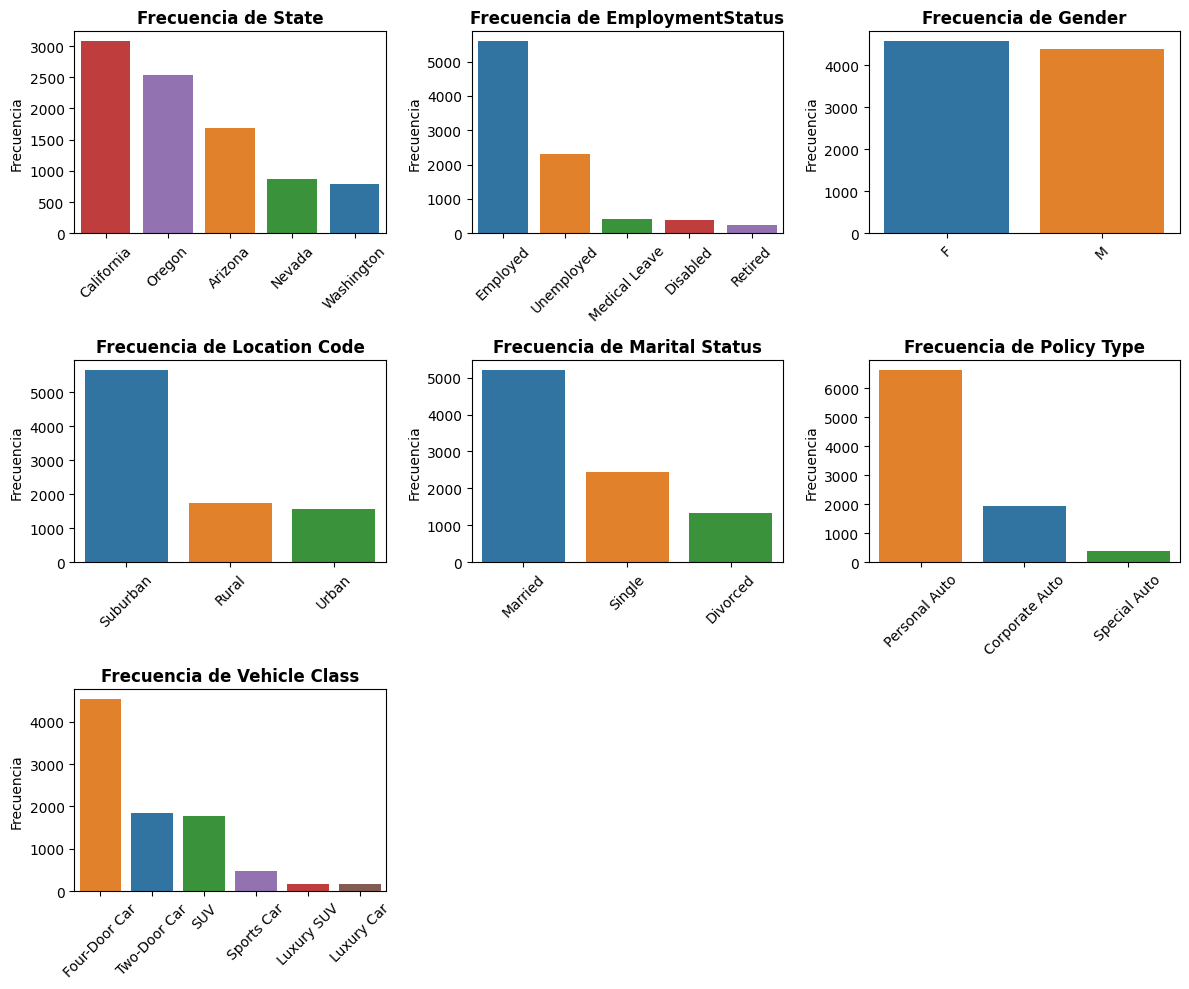

In [9]:
# Dibujar gráfico de barras para cada variable categórica
nominal_columns = ['State', 'EmploymentStatus', 'Gender', 'Location Code', 'Marital Status', 'Policy Type', 'Vehicle Class']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(nominal_columns):
    # Crear el gráfico en el eje específico (ax=axes[i])
    sns.countplot(
        data=df_1,
        x=col, 
        hue=col, 
        order=df_1[col].value_counts().index, 
        ax=axes[i],
        legend= False
    )
    
    # Configurar títulos y etiquetas para cada subgráfico
    axes[i].set_title(f'Frecuencia de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') # Quitamos el nombre del eje X para no saturar
    axes[i].set_ylabel('Frecuencia')
    
    # Rotar las etiquetas del eje X si son muy largas
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(nominal_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Evitar solapamiento de subgráficos
plt.show()

Las frecuencias para las variables nominales tienen sentido, veamos ahora las variables ordinales.

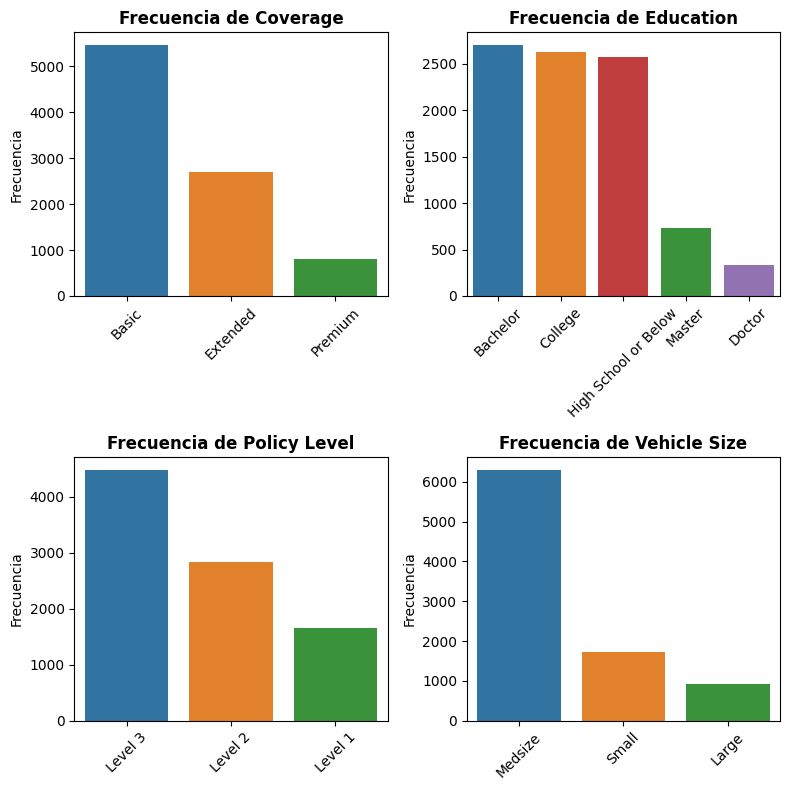

In [10]:
# Dibujar gráfico de barras para cada variable categórica
ordinal_columns = ['Coverage', 'Education', 'Policy Level', 'Vehicle Size']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))
axes = axes.flatten()
for i, col in enumerate(ordinal_columns):
    # Crear el gráfico en el eje específico (ax=axes[i])
    sns.countplot(
        data=df_1,
        x=col, 
        hue=col, 
        order=df_1[col].value_counts().index, 
        ax=axes[i],
        legend= False
    )
    
    # Configurar títulos y etiquetas para cada subgráfico
    axes[i].set_title(f'Frecuencia de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') # Quitamos el nombre del eje X para no saturar
    axes[i].set_ylabel('Frecuencia')
    
    # Rotar las etiquetas del eje X si son muy largas
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout() # Evitar solapamiento de subgráficos
plt.show()

Una vez hemos detectado las variables categóricas pasamos a codificarlas, lo cual nos permitirá tratarlas desde el punto de vista matemático e incluirlas en análisis estadísticos como el PCA o el clustering. Las variables categóricas nominales que consideremos de interés para la aplicación de técnicas estadísticas las codificaremos en variables _Dummy_ mediante la técnica _One-Hot Encoding_ y las variables ordinales correspondientes se codificarán de manera ordenada.


In [11]:
# Codificar las variables categóricas nominales utilizando one-hot encoding
variables_nominales = ['EmploymentStatus', 'Location Code', 'Policy Type', 'Vehicle Class']
df_1 = pd.get_dummies(df_1, columns=variables_nominales, drop_first=True)

# Codificar las variables categóricas ordinales utilizando label encoding
variables_ordinales = ['Coverage', 'Education', 'Policy Level', 'Vehicle Size']
le = LabelEncoder()
for var in variables_ordinales:
    df_1[var] = le.fit_transform(df_1[var]) 
df_1.head()

,Customer,State,Customer Lifetime Value,Coverage,Education,Effective To Date,Gender,Income,Marital Status,Monthly Premium Auto,...,EmploymentStatus_Unemployed,Location Code_Suburban,Location Code_Urban,Policy Type_Personal Auto,Policy Type_Special Auto,Vehicle Class_Luxury Car,Vehicle Class_Luxury SUV,Vehicle Class_SUV,Vehicle Class_Sports Car,Vehicle Class_Two-Door Car
0,BU79786,Washington,2763.519279,0,0,2011-02-24,F,56274,Married,69,...,False,True,False,False,False,False,False,False,False,True
1,QZ44356,Arizona,6979.535903,1,0,2011-01-31,F,0,Single,94,...,True,True,False,True,False,False,False,False,False,False
2,AI49188,Nevada,12887.431650,2,0,2011-02-19,F,48767,Married,108,...,False,True,False,True,False,False,False,False,False,True
3,WW63253,California,7645.861827,0,0,2011-01-20,M,0,Married,106,...,True,True,False,False,False,False,False,True,False,False
4,HB64268,Washington,2813.692575,0,0,2011-02-03,M,43836,Single,73,...,False,False,False,True,False,False,False,False,False,False


### Tratamiento Variables Explicativas Numéricas

Identificamos y definimos nuestras variables numéricas:

- `Customer Lifetime Value`. Toma valores decimales, representa el valor presente neto que generará el cliente durante toda su relación con la aseguradora. 
- `Income`. El ingreso anual reportado por el cliente, toma valores enteros.
- `Monthly Premium Auto`. Es la prima mensual que paga el cliente por su seguro de coche. Toma valores enteros
- `Months Since Last Claim`. El número de meses que han transcurrido desde la última reclamación. Es una variable discreta
- `Months Since Policy Inception`. El número de meses desde que el cliente contrató la póliza. Es una variable discreta.
- `Number of Open Complaints`. El número de reclamaciones activas o abiertas, es un valor entero (variable discreta)
- `Number of Policies`. El número de pólizas que el cliente tiene contratadas con la aseguradora, el número de vehículos asegurados, toma valores enteros y es una variable discreta.
- `Total Claim Ammunt`. Cuantía total acumulada que la aseguradora ha pagado por los reclamos de ese cliente

Comenzamos con un resumen estadístico de estas variables:



In [12]:
numerical_columns = ['Customer Lifetime Value', 'Income', 'Monthly Premium Auto', 
            'Months Since Last Claim', 'Months Since Policy Inception', 
            'Number of Open Complaints', 'Number of Policies', 'Total Claim Amount']

df_num = df_1[numerical_columns].copy()
display(df_num.describe().round(2))

,Customer Lifetime Value,Income,Monthly Premium Auto,Months Since Last Claim,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Total Claim Amount
count,8971.00,8971.00,8971.00,8971.00,8971.00,8971.00,8971.00,8971.00
mean,8004.19,37644.83,93.19,15.10,48.05,0.39,2.97,433.89
std,6867.94,30431.74,34.36,10.08,27.92,0.91,2.39,291.07
min,1898.01,0.00,61.00,0.00,0.00,0.00,1.00,0.10
25%,3999.50,0.00,68.00,6.00,24.00,0.00,1.00,270.47
50%,5792.44,33947.00,83.00,14.00,48.00,0.00,2.00,383.44
75%,8954.64,62365.50,109.00,23.00,71.00,0.00,4.00,547.98
max,83325.38,99981.00,298.00,35.00,99.00,5.00,9.00,2893.24


En este pequeño resumen estadístico apreciamos algunas métricas muy interesantes. La variable `Income` tiene un cuartil para el cual los ingresos reportados son 0; este es un valor asociado al desempleo, si el 25% de nuestra muestra se encuentra en situación de desempleo este dato podría tener sentido pero en otro caso debemos de tratar esta variable si queremos usarla. El máximo de meses desde que se contrato la póliza es 99, según define la variable `Months Since Policy Inception`. El número de reclamaciones abiertas, recogido en la variable de `Number of Open Complaints` es 0 para más del 75% de la muestra, sin embargo este dato parece tener sentido ya que no es habitual que haya demasiados siniestros sin liquidar. El valor mínimo para la cuantía pagada en relación a la severidad de los siniestros es 0.1 unidades monetarias, este valor no parece tener mucho sentido. Procedamos a un análisis visual de nuestras variables  numéricas para detectar todas las incosistencias antes de empezar a tratar con ellas.

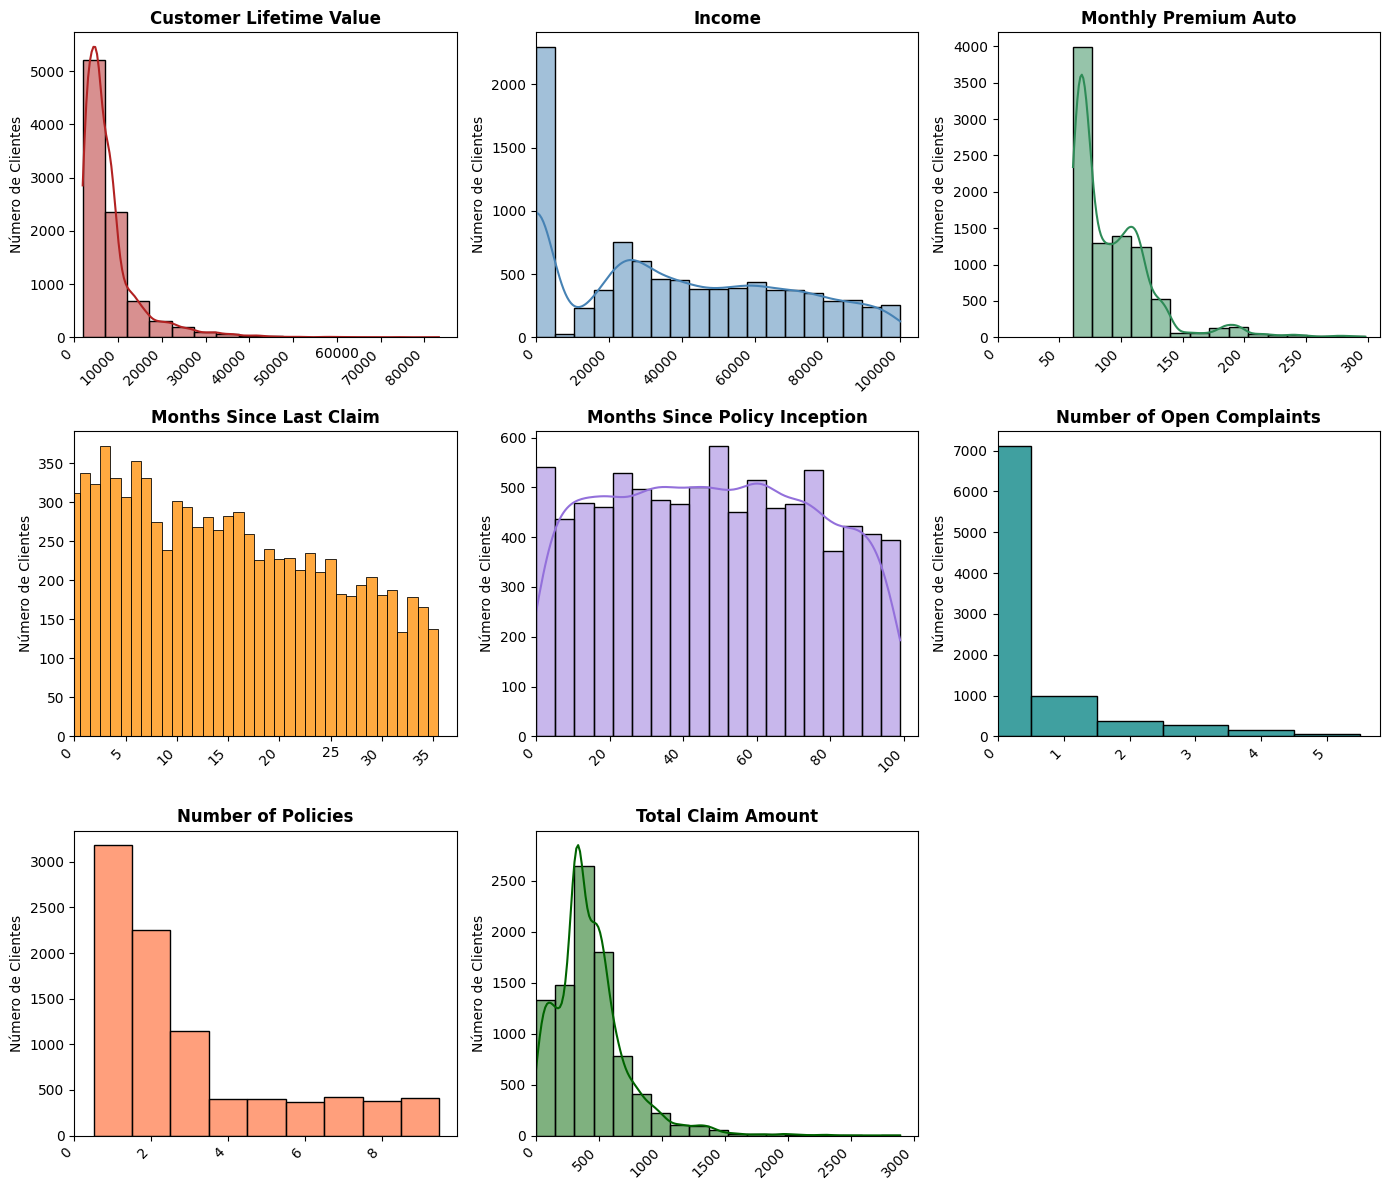

In [19]:
# Dibujar histogramas para cada variable numérica

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 12))
axes = axes.flatten()
colors = ['firebrick', 'steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'teal', 'coral', 'darkgreen']
for i, col in enumerate(numerical_columns):
    # Ajustamos el tamaño de los intervalos del histograma utilizando el máximo y mínimo de cada variable para definir los bins
    min_val = df_num[col].min()
    max_val = df_num[col].max()

    if max_val - min_val < 50:      # Si el rango es menor a 50, usamos un bin por cada unidad
        sns.histplot(
            data=df_num,
            x=col, 
            ax=axes[i],
            discrete=True, # Centra y ensancha las barras en los números enteros
            kde=False,     # La curva de densidad no aporta mucho en datos discretos
            color=colors[i]
        )
    else:
        if max_val - min_val < 100:   # Si el rango es menor a 500, usamos un bin por cada 25 unidades
            nbins = int((max_val - min_val) / 5)
        elif max_val - min_val < 500:   # Si el rango es menor a 500, usamos un bin por cada 25 unidades
            nbins = int((max_val - min_val) / 15)
        elif max_val - min_val < 10000:  # Si el rango es menor a 1000, usamos un bin por cada 50 unidades
            nbins = int((max_val - min_val) / 150)
        else:                           # Si el rango es mayor a 1000, usamos un bin por cada 100 unidades
            nbins = int((max_val - min_val) / 5000)

        sns.histplot(
            data=df_num,
            x=col, 
            ax=axes[i],
            bins=nbins,    
            kde=True, 
            color=colors[i]
        )
    
    # Configurar títulos y etiquetas para cada subgráfico
    axes[i].set_xlim(left=0)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('') # Quitamos el nombre del eje X para no saturar
    axes[i].set_ylabel('Número de Clientes')
    
    # Rotar las etiquetas del eje X si son muy largas
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha='right')

for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Evitar solapamiento de subgráficos
plt.show()

A primera vista tan solo nos llama la atención el dato de `Income` donde vemos que más de 2000 clientes reportan 0 ingresos. Vamos a cruzar estos datos con los de la variable `EmploymentStatus` para ver si tienen sentido o son datos missing.

In [25]:
# Vemos a que grupo de clientes según el employment status pertenecen los clientes sin ingresos reportados (Income = 0)
clientes_sin_ingresos = df_limpio[df_limpio['Income'] == 0]
print(clientes_sin_ingresos['EmploymentStatus'].value_counts())


EmploymentStatus
Unemployed    2296
Name: count, dtype: int64


Con lo cual comprobamos que este dato de 0`s si bien puede llamar la atención, no se asocia con clientes que no reporten ingresos a pesar de que los tengan, pues todos son desempleados.

Veamos que valores bajos toma la variable `Total Claim Amount` y como los podemos interpretar.

In [34]:
severidad_baja = df_1[df_1['Total Claim Amount'] <=10]
display(severidad_baja['Total Claim Amount'].describe().round(2))
# Cruzamos los clientes con severidad baja con la variable de siniestros abiertos (Number of Open Complaints)
print(severidad_baja['Number of Open Complaints'].value_counts())
# Cruzamos los clientes con severidad baja con las últimas polizas contradas (Months Since Policy Inception) y con los últimos siniestros (Months Since Last Claim)
print(severidad_baja[severidad_baja['Months Since Policy Inception']<=5]['Months Since Policy Inception'].value_counts())
print(severidad_baja[severidad_baja['Months Since Last Claim']<=5]['Months Since Last Claim'].value_counts())

count    89.00
mean      5.37
std       2.80
min       0.10
25%       2.96
50%       5.62
75%       7.65
max       9.83
Name: Total Claim Amount, dtype: float64

Number of Open Complaints
0    68
1    12
3     5
2     4
Name: count, dtype: int64
Months Since Policy Inception
5    4
4    2
2    1
0    1
1    1
Name: count, dtype: int64
Months Since Last Claim
2    7
4    4
1    4
5    3
0    3
3    1
Name: count, dtype: int64


Esta distribución de los datos con cantidades totales tan bajas par casos en los que hay hasta 3 siniestros abiertos nos confirma que esto es ruido que se ha producido por la generación artificial de estos datos sintéticos. Vamos a proceder a detectar cuantas de estas severidades podemos identificar como ruido sintético y no como severidades que se ajusten a una muestra real de los datos. Establecemos el umbral para el cual consideramos que los siniestros son anómalos en 10 unidades monetarias. Todos los clientes cuya severidad total sea inferior a 10 se eliminan.

In [41]:
df_1 = df_1[df_1['Total Claim Amount'] > 10]

A continuación, sacaremos las correlaciones de nuestras variables para saber cuales de ellas pueden mostrar una dependencia.

<Axes: >

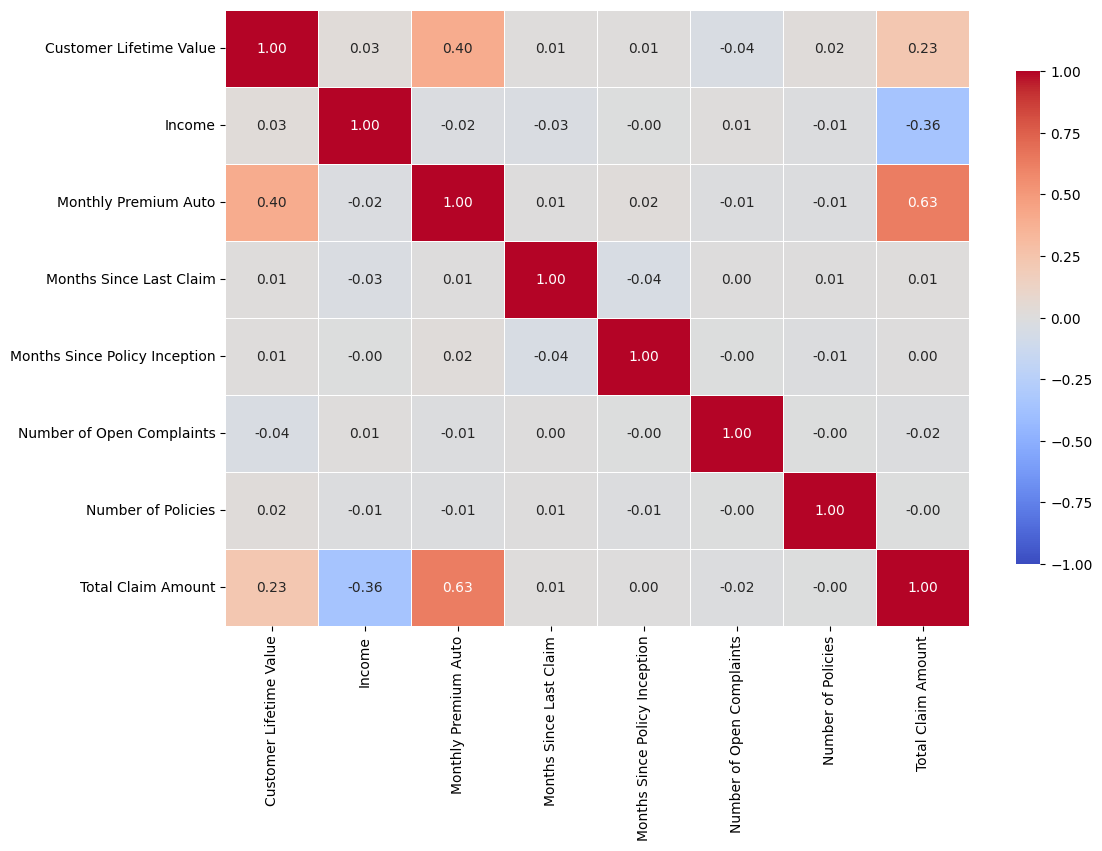

In [26]:
corr_matrix = df_num.corr()
plt.figure(figsize=(12, 8))
# En lugar de visualizar la matriz de correlaciones vemos un mapa de calor con los valores de correlación
sns.heatmap(
    corr_matrix, 
    annot=True,              # Muestra los valores numéricos de correlación en las celdas
    fmt=".2f",               # Formatea los números a 2 decimales
    cmap='coolwarm',         # Paleta de colores divergente (azul para negativa, rojo para positiva)
    vmin=-1, vmax=1,         # Fijamos los límites de la escala de color entre -1 y 1
    linewidths=0.5,          # Añade unas pequeñas líneas entre celdas para que se vea más limpio
    cbar_kws={"shrink": .8}  # Ajusta un poco el tamaño de la barra de color lateral
)

La única correlación que supera el 0.5 es la que hay entre las variables de prima mensual y el monto total de las reclamaciones. La prima mensual no es un predictor de la suma total de las reclamaciones pues la idea es calcular una en base a la otra. Esta correlación no debe preocuparnos demasiado